# Cluster Theory Prediction Tutorial

## 1. Introduction
`clpipe.cluster_theory_pred` computes the cluster observables predicted by a CLPipe configuration and compares them with the measured data vector.

It builds the same Firecrown likelihood that the `CLPFirecrown` stage writes to `likelihood_file.py` (halo mass function, mass-richness relation, completeness and purity, CROW recipe and grid sizes) and evaluates it at one point of parameter space. The predictions are therefore the ones the chain computes at that point.

Use it to check a configuration against the data before launching a chain, to plot the model at the best fit of a chain, or to see how a modelling choice (halo mass function, selection function) changes the prediction.

In this tutorial we use the cosmoDC2 redMaPPer baseline analysis (number counts and stacked $\Delta\Sigma$) in `examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both`.

## 2. Requirements
- The `firecrown_clp` kernel (see `tutorials/README.md`).
- The example data, downloaded into `CLPipe/data/` with the `wget` command of the main `README.md`. We use
  - `data/cosmodc2_redmapper/sacc/full_both_cov.sacc`: data vector and covariance of the baseline run (the `clusters_sacc_file_cov` file),
  - `data/cosmodc2_redmapper/chains/bestfit_full_both.txt`: best fit of the counts + lensing chain, written by `examples/cosmodc2_redmapper/plot_samples.ipynb`.

In [1]:
import sys
sys.path.append("../../")  # not needed if CLPipe is installed with `pip install -e .`
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import yaml

from clpipe.cluster_theory_pred import compute_cluster_predictions

# CROW warns when the shear profile is created without a concentration. The
# value in firecrown_parameters is set before every evaluation, as in the chain.
warnings.filterwarnings("ignore", message="The concentration value")

RUN_DIR = "../../examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both"
CONFIG = f"{RUN_DIR}/config_in2p3_both.yml"
SACC_FILE = "../../data/cosmodc2_redmapper/sacc/full_both_cov.sacc"
BESTFIT_FILE = "../../data/cosmodc2_redmapper/chains/bestfit_full_both.txt"
FIDUCIAL_COSMOLOGY = "fiducial_cosmology.yml"

## 3. Inputs
`compute_cluster_predictions` takes the same inputs as the `CLPFirecrown` stage:

1. **Configuration file**, the one used to run the pipeline. Only its `CLPFirecrown` section is read, and options missing from it take the stage defaults.
2. **SACC file** with the data vector and its covariance (`clusters_sacc_file_cov`).
3. **Fiducial cosmology** (`fiducial_cosmology`). The file in this folder is a copy of the cosmoDC2 one used at CC-IN2P3, `/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/fiducial_cosmology.yml`.

The model options and parameter blocks of the baseline configuration:

In [2]:
cfg = yaml.safe_load(open(CONFIG))["CLPFirecrown"]
for key in ["hmf", "mass_def", "min_mass", "max_mass", "use_completeness", "use_purity", "use_grid", "is_deltasigma"]:
    print(f"{key:18s} {cfg[key]}")

print("\ncosmological_parameters (CosmoSIS names, on top of the fiducial cosmology)")
for name, spec in cfg["cosmological_parameters"].items():
    print(f"  {name:38s} {spec}")
print("\nfirecrown_parameters")
for name, spec in cfg["firecrown_parameters"].items():
    print(f"  {name:38s} {spec}")

hmf                despali16
mass_def           200c
min_mass           12.0
max_mass           15.5
use_completeness   True
use_purity         False
use_grid           True
is_deltasigma      True

cosmological_parameters (CosmoSIS names, on top of the fiducial cosmology)
  omega_c                                {'sample': True, 'values': [0.1, 0.22, 0.5]}
  sigma_8                                {'sample': True, 'values': [0.5, 0.8, 1.1]}

firecrown_parameters
  mass_distribution_mu0                  {'sample': True, 'values': [2.0, 3.3439, 10.0]}
  mass_distribution_mu1                  {'sample': True, 'values': [0.5, 0.958236982, 2.0]}
  mass_distribution_mu2                  {'sample': True, 'values': [-2.0, -0.0192802, 2.0]}
  mass_distribution_sigma0               {'sample': True, 'values': [0.1, 0.562317194, 2.0]}
  mass_distribution_sigma1               {'sample': True, 'values': [-0.6, 0.04552506, 0.3]}
  mass_distribution_sigma2               {'sample': True, 'values': [-0.

## 4. Prediction at the starting point of the chain
Without the `params` argument, the parameter values are the ones `CLPFirecrown` writes to `priors_file.ini`:
- the cosmology comes from the fiducial file, with the `cosmological_parameters` entries on top of it,
- a fixed parameter takes its value, and a sampled parameter its starting value (the middle entry of `values`).

In [3]:
fid = compute_cluster_predictions(CONFIG, SACC_FILE, FIDUCIAL_COSMOLOGY)

n_data = len(fid.counts.data) + len(fid.shear.data)
print(f"chi2 = {fid.chi2:.1f} for {n_data} data points\n")
for name, value in fid.parameters.items():
    print(f"{name:38s} {value}")

chi2 = 246.2 for 192 data points

Neff                                   3.046
Omega_b                                0.0448
Omega_c                                0.22
Omega_k                                0.0
T_CMB                                  2.725
h                                      0.71
m_nu                                   []
n_s                                    0.963
sigma8                                 0.8
w0                                     -1.0
wa                                     0.0
cluster_theory_cluster_concentration   3.8
completeness_a_logm_piv                13.31
completeness_a_n                       1.1321
completeness_b_logm_piv                0.2025
completeness_b_n                       0.7751
mass_distribution_mu0                  3.3439
mass_distribution_mu1                  0.958236982
mass_distribution_mu2                  -0.0192802
mass_distribution_sigma0               0.562317194
mass_distribution_sigma1               0.04552506
mass_dis

The result has four attributes:
- `counts` and `shear`: one `BinnedPrediction` per statistic (None when the statistic is switched off in the configuration). Each holds `theory`, `data`, `covariance`, `errors`, `z_edges`, `proxy_edges` ($\log_{10}$ richness), `radius` (shear only) and `sacc_indices`, all in the order of the SACC data vector.
- `chi2`: chi-squared of the whole likelihood with the full covariance.
- `parameters`: the values used, with CCL names for the cosmology and Firecrown names for the cluster parameters.

The first counts bins:

In [4]:
c = fid.counts
print(f"{'z bin':>11s} {'richness bin':>14s} {'data':>7s} {'theory':>8s} {'error':>6s}")
for i in range(6):
    (z0, z1), (l0, l1) = c.z_edges[i], 10 ** c.proxy_edges[i]
    print(f"{z0:.1f} - {z1:.1f} {l0:6.0f} - {l1:5.0f} {c.data[i]:7.0f} {c.theory[i]:8.1f} {c.errors[i]:6.1f}")

      z bin   richness bin    data   theory  error
0.2 - 0.3     20 -    35     142    140.8   14.1
0.3 - 0.4     20 -    35     255    219.1   17.2
0.4 - 0.5     20 -    35     305    281.7   19.0
0.5 - 0.6     20 -    35     362    320.5   19.8
0.6 - 0.7     20 -    35     377    333.9   19.8
0.7 - 0.8     20 -    35     312    325.2   19.3


## 5. Prediction at the chain best fit
The `params` argument replaces configuration values. Its keys can be
- CosmoSIS names (`omega_c`, `sigma_8`), as in the configuration,
- CCL names (`Omega_c`, `sigma8`),
- Firecrown names (`mass_distribution_mu0`).

Names with the section prefix of the CosmoSIS chain files (`cosmological_parameters--omega_c`, `firecrown_number_counts--mass_distribution_mu0`) also work, so a row of a chain can be passed directly. The best-fit file below uses LaTeX labels, so we map them to the configuration names first.

In [5]:
LATEX_TO_PARAMETER = {
    r"\Omega_c": "omega_c",
    r"\sigma_8": "sigma_8",
    r"\mu_0": "mass_distribution_mu0",
    r"\mu_m": "mass_distribution_mu1",
    r"\mu_z": "mass_distribution_mu2",
    r"\sigma_0": "mass_distribution_sigma0",
    r"\sigma_m": "mass_distribution_sigma1",
    r"\sigma_z": "mass_distribution_sigma2",
}

bestfit = {}
with open(BESTFIT_FILE) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        label, best_value, _mean = line.split()
        bestfit[LATEX_TO_PARAMETER[label]] = float(best_value)

for name, value in bestfit.items():
    print(f"{name:26s} {value:.4f}")

best = compute_cluster_predictions(CONFIG, SACC_FILE, FIDUCIAL_COSMOLOGY, params=bestfit)

omega_c                    0.2154
sigma_8                    0.7959
mass_distribution_mu0      3.3970
mass_distribution_mu1      0.9015
mass_distribution_mu2      -0.3906
mass_distribution_sigma0   0.5233
mass_distribution_sigma1   0.0554
mass_distribution_sigma2   0.4670


Chi-squared of each statistic (with its own covariance block) and of the whole likelihood:

In [6]:
def block_chi2(prediction):
    residual = prediction.data - prediction.theory
    return residual @ np.linalg.solve(prediction.covariance, residual)

print(f"{'':16s} {'counts':>8s} {'DeltaSigma':>11s} {'total':>8s}")
print(f"{'data points':16s} {len(fid.counts.data):8d} {len(fid.shear.data):11d} {n_data:8d}")
for label, prediction in [("starting point", fid), ("best fit", best)]:
    print(f"{label:16s} {block_chi2(prediction.counts):8.1f} {block_chi2(prediction.shear):11.1f} {prediction.chi2:8.1f}")

                   counts  DeltaSigma    total
data points            24         168      192
starting point       34.6       211.6    246.2
best fit             24.0       206.8    230.8


## 6. Number counts
Measured counts with their errors (square root of the covariance diagonal) and the two predictions, in each redshift bin.

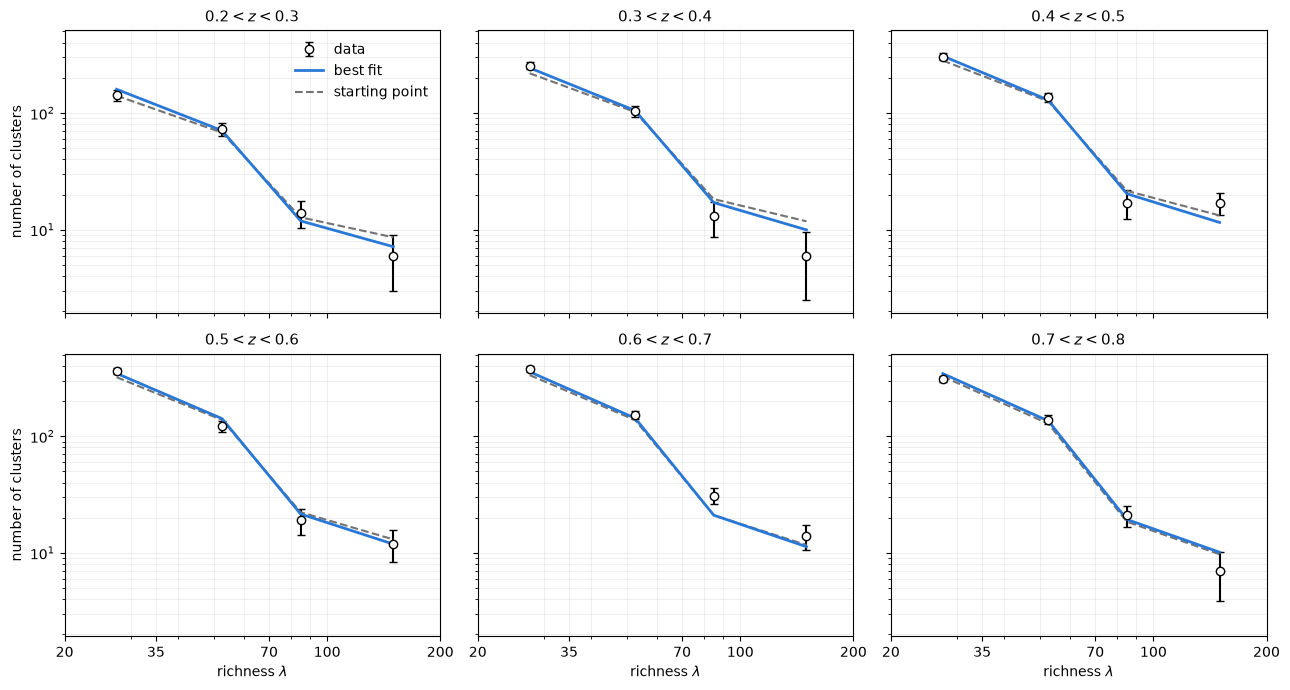

In [7]:
def bin_groups(edges):
    # Unique bins, in the order they appear in the data vector
    unique = []
    for e in map(tuple, edges):
        if e not in unique:
            unique.append(e)
    return unique

c_fid, c_best = fid.counts, best.counts
z_bins = bin_groups(c_fid.z_edges)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, (z0, z1) in zip(axes.flat, z_bins):
    sel = np.all(c_fid.z_edges == (z0, z1), axis=1)
    richness = 0.5 * (10 ** c_fid.proxy_edges[sel, 0] + 10 ** c_fid.proxy_edges[sel, 1])
    ax.errorbar(richness, c_fid.data[sel], yerr=c_fid.errors[sel], fmt="o", color="black",
                mfc="white", ms=6, capsize=3, label="data")
    ax.plot(richness, c_fid.theory[sel], ls="--", lw=1.5, color="0.45", label="starting point")
    ax.plot(richness, c_best.theory[sel], ls="-", lw=2, color="#2a78d6", label="best fit")
    ax.set_title(f"${z0:.1f} < z < {z1:.1f}$", fontsize=11)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks([20, 35, 70, 100, 200])
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(alpha=0.3, which="both", lw=0.5)
for ax in axes[1]:
    ax.set_xlabel(r"richness $\lambda$")
for ax in axes[:, 0]:
    ax.set_ylabel("number of clusters")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handles[::-1], labels[::-1], frameon=False)  # data first
fig.tight_layout()

## 7. Stacked $\Delta\Sigma$ profiles
One panel per redshift bin and one colour per richness bin. Points are the data, solid lines the best fit and dashed lines the starting point.

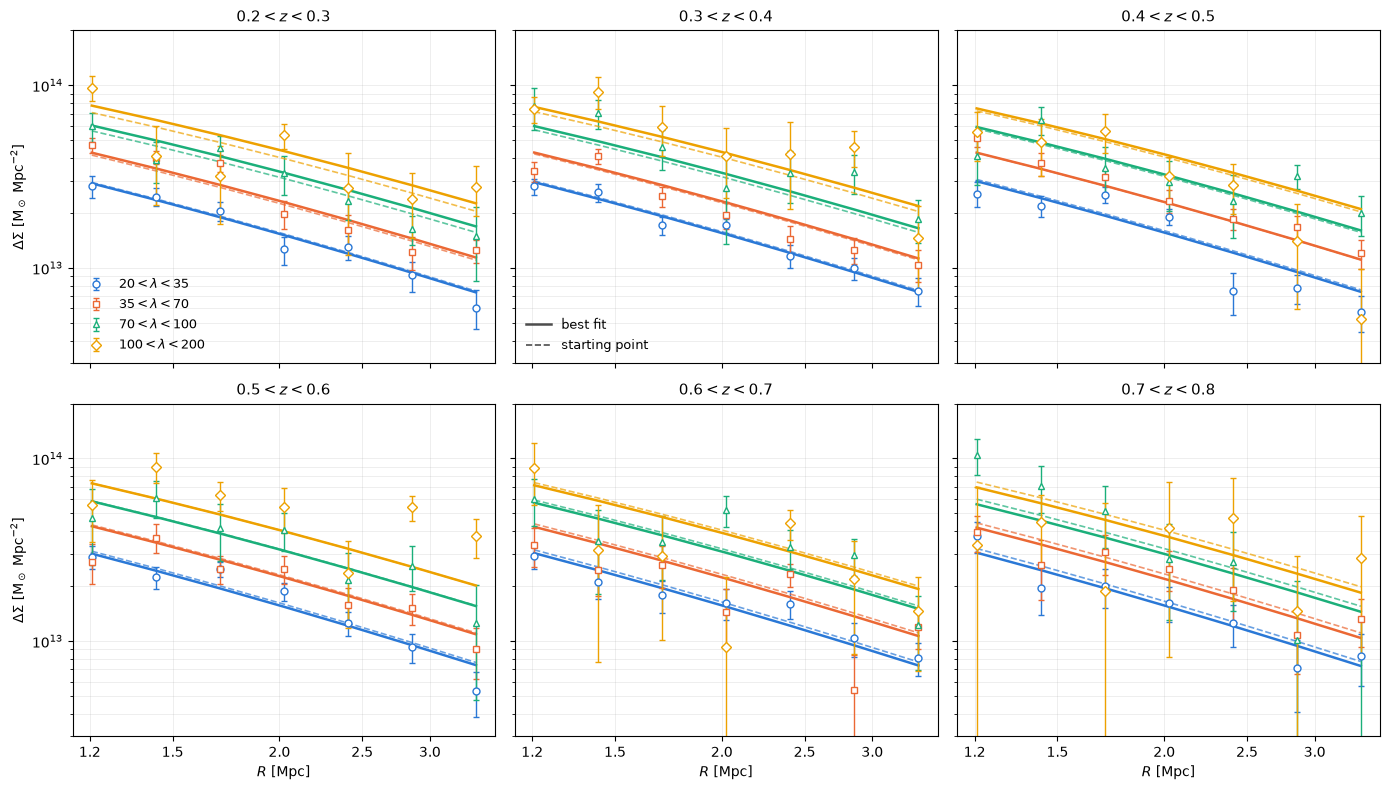

In [8]:
s_fid, s_best = fid.shear, best.shear
richness_bins = bin_groups(s_fid.proxy_edges)
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
markers = ["o", "s", "^", "D"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, (z0, z1) in zip(axes.flat, bin_groups(s_fid.z_edges)):
    for (l0, l1), color, marker in zip(richness_bins, colors, markers):
        sel = np.all(s_fid.z_edges == (z0, z1), axis=1) & np.all(s_fid.proxy_edges == (l0, l1), axis=1)
        radius = s_fid.radius[sel]
        ax.errorbar(radius, s_fid.data[sel], yerr=s_fid.errors[sel], fmt=marker, color=color,
                    mfc="white", ms=5, capsize=2, lw=1,
                    label=rf"${10**l0:.0f} < \lambda < {10**l1:.0f}$")
        ax.plot(radius, s_best.theory[sel], ls="-", lw=1.8, color=color)
        ax.plot(radius, s_fid.theory[sel], ls="--", lw=1.2, color=color, alpha=0.7)
    ax.set_title(f"${z0:.1f} < z < {z1:.1f}$", fontsize=11)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(3e12, 2e14)  # error bars of the noisiest bins reach zero
    ax.set_xticks([1.2, 1.5, 2, 2.5, 3])
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(alpha=0.3, which="both", lw=0.5)
for ax in axes[1]:
    ax.set_xlabel(r"$R$ [Mpc]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\Delta\Sigma$ [M$_\odot$ Mpc$^{-2}$]")
axes[0, 0].legend(frameon=False, fontsize=9, loc="lower left")
axes[0, 1].legend(
    [plt.Line2D([], [], color="0.3", lw=1.8), plt.Line2D([], [], color="0.3", lw=1.2, ls="--")],
    ["best fit", "starting point"], frameon=False, fontsize=9, loc="lower left",
)
fig.tight_layout()

## 8. Changing a modelling choice
The configuration can also be given as a dictionary, so a modelling choice can be changed without editing the YAML file. Here we evaluate the best fit with other halo mass functions, as in `examples/cosmodc2_redmapper/hmf_analysis`. Only the halo mass function changes, the parameters stay at the best fit of the baseline (Despali16) chain.

In [9]:
pipeline_config = yaml.safe_load(open(CONFIG))

print(f"{'hmf':10s} {'counts chi2':>12s} {'DeltaSigma chi2':>16s} {'total chi2':>11s}")
for hmf in ["despali16", "tinker08", "tinker10", "bocquet16"]:
    pipeline_config["CLPFirecrown"]["hmf"] = hmf
    prediction = compute_cluster_predictions(pipeline_config, SACC_FILE, FIDUCIAL_COSMOLOGY, params=bestfit)
    print(f"{hmf:10s} {block_chi2(prediction.counts):12.1f} {block_chi2(prediction.shear):16.1f} {prediction.chi2:11.1f}")

hmf         counts chi2  DeltaSigma chi2  total chi2


despali16          24.0            206.8       230.8


tinker08           25.5            207.8       233.2


tinker10           74.6            207.7       282.2


bocquet16          58.4            207.3       265.7


## 9. Notes
- **Parameter values.** For the cosmology the order of precedence is the Firecrown default, then the fiducial file, then `cosmological_parameters`, then `params`. For the cluster parameters it is `firecrown_parameters`, then `params`.
- **Missing parameters.** A parameter the likelihood needs and that is neither in `firecrown_parameters` nor in `params` raises an error, as it would in the chain. For example, `use_purity: true` needs the four `purity_*` parameters.
- **Fixed cosmology.** A fixed `cosmological_parameters` entry that differs from the fiducial cosmology raises the same error as `CLPFirecrown`.
- **Power spectrum.** Here CCL computes the linear matter power spectrum (with CAMB), while in the chain it comes from the CosmoSIS CAMB module. The chi-squared values can therefore differ slightly from the ones in the chain output.
- **Older interface.** `build_cluster_recipes_from_config(config, sacc_file, set_params, fiducial_cosmology=...)` returns the tuple `(counts_theory, counts_data, shear_theory, shear_data)`.